In [6]:
import os
from langgraph.graph import StateGraph,START,END
from langchain.chat_models import init_chat_model

In [7]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000261D73EED50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000261D73EF750>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

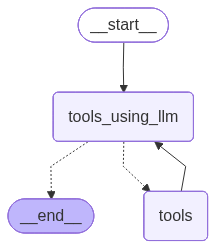

In [15]:
from typing import Annotated
from langchain_core.tools import tool

from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import TypedDict
from IPython.display import Image,display

from langgraph.types import Command ,  interrupt
memory = MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]
    
graph_builder = StateGraph(State)

@tool
def human_assistence(query:str)->str:
    """Request assistance from a human"""
    human_response = interrupt({"query":query})
    return human_response["data"]
tool = TavilySearch(max_results = 2)
tools = [tool,human_assistence]
llm_with_tools = llm.bind_tools(tools)

def tools_using_llm(state:State):
    message = llm_with_tools.invoke(state["messages"])
    
    return {"messages":[message]}

graph_builder.add_node("tools_using_llm",tools_using_llm)
tool_node = ToolNode(tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_edge(START,"tools_using_llm")
graph_builder.add_conditional_edges("tools_using_llm",tools_condition)
graph_builder.add_edge("tools","tools_using_llm")

graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

    

In [16]:
config = {"configurable":{"thread_id":"1"}}
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"

events = graph.stream({"messages":user_input},config=config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistence (8b3d3ed3w)
 Call ID: 8b3d3ed3w
  Args:
    query: I need expert guidance and assistance for building an AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistence (8b3d3ed3w)
 Call ID: 8b3d3ed3w
  Args:
    query: I need expert guidance and assistance for building an AI agent


In [17]:
human_response = ("We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents.")
human_command = Command(resume={"data":human_response})

events = graph.stream(human_command,config=config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistence (8b3d3ed3w)
 Call ID: 8b3d3ed3w
  Args:
    query: I need expert guidance and assistance for building an AI agent
================================= Tool Message =================================
Name: human_assistence

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I hope you receive the guidance and assistance you need to build your AI agent. If you have any further questions or need additional help, feel free to ask.
